# Imports

In [1]:
import numpy as np
import sympy as sp
from numba import njit, prange

Mis funciones definidas en `/code/src/`

In [2]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted
from utils import DynamicsPlotter

# Ejemplo del libro ($z \mapsto z^2 + c$)

El conjunto de Mandelbrot se obtiene fijando $z_0 = 0$ y viendo para que valores de $c$ la función $z \mapsto z^2 + c$ no diverge. Veámoslo.

In [3]:
@njit(parallel=True)
def generate_escape_times_for_mandelbrot_set(x_min, x_max, y_min, y_max, width, height, max_iter=100, escape_radius=2.0):
    escape_times = np.zeros((height, width), dtype=np.int64)
    x_coords = np.linspace(x_min, x_max, width)
    y_coords = np.linspace(y_min, y_max, height)

    for i in prange(height):
        for j in range(width):
            c = complex(x_coords[j], y_coords[i])
            z = 0
            iters = 0
            while abs(z) <= escape_radius and iters < max_iter:
                z = z*z + c
                iters += 1
            escape_times[i, j] = iters

    return escape_times

In [ ]:
center = -0.75
max_distance_to_center = 1.4

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 100

escape_times_mandelbrot = generate_escape_times_for_mandelbrot_set(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=2.0)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Mandelbrot Set (Escape Time Fractal)'}>)

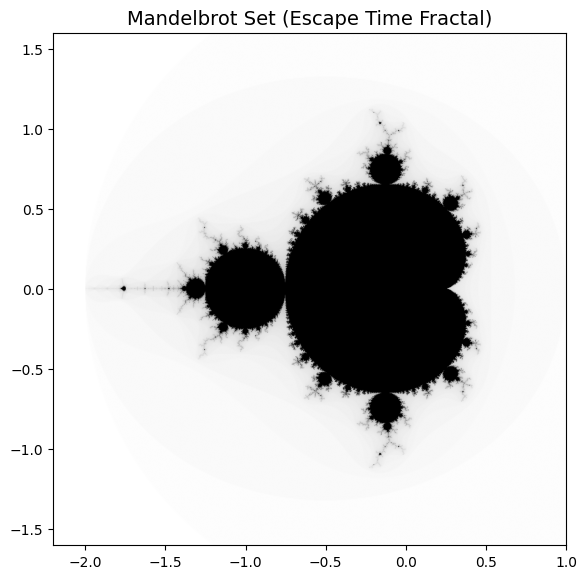

In [17]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_escape_time_fractal(escape_times_mandelbrot, title="Mandelbrot Set (Escape Time Fractal)")

Quería verlo más grande.

In [27]:
center = -0.6
max_distance_to_center = 1.6

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 10000
vertical_pixels = 10000

max_iter = 256

escape_times_mandelbrot = generate_escape_times_for_mandelbrot_set(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=2.0)

(<Figure size 1800x1800 with 2 Axes>,
 <Axes: title={'center': 'Mandelbrot Set (Escape Time Fractal)'}>)

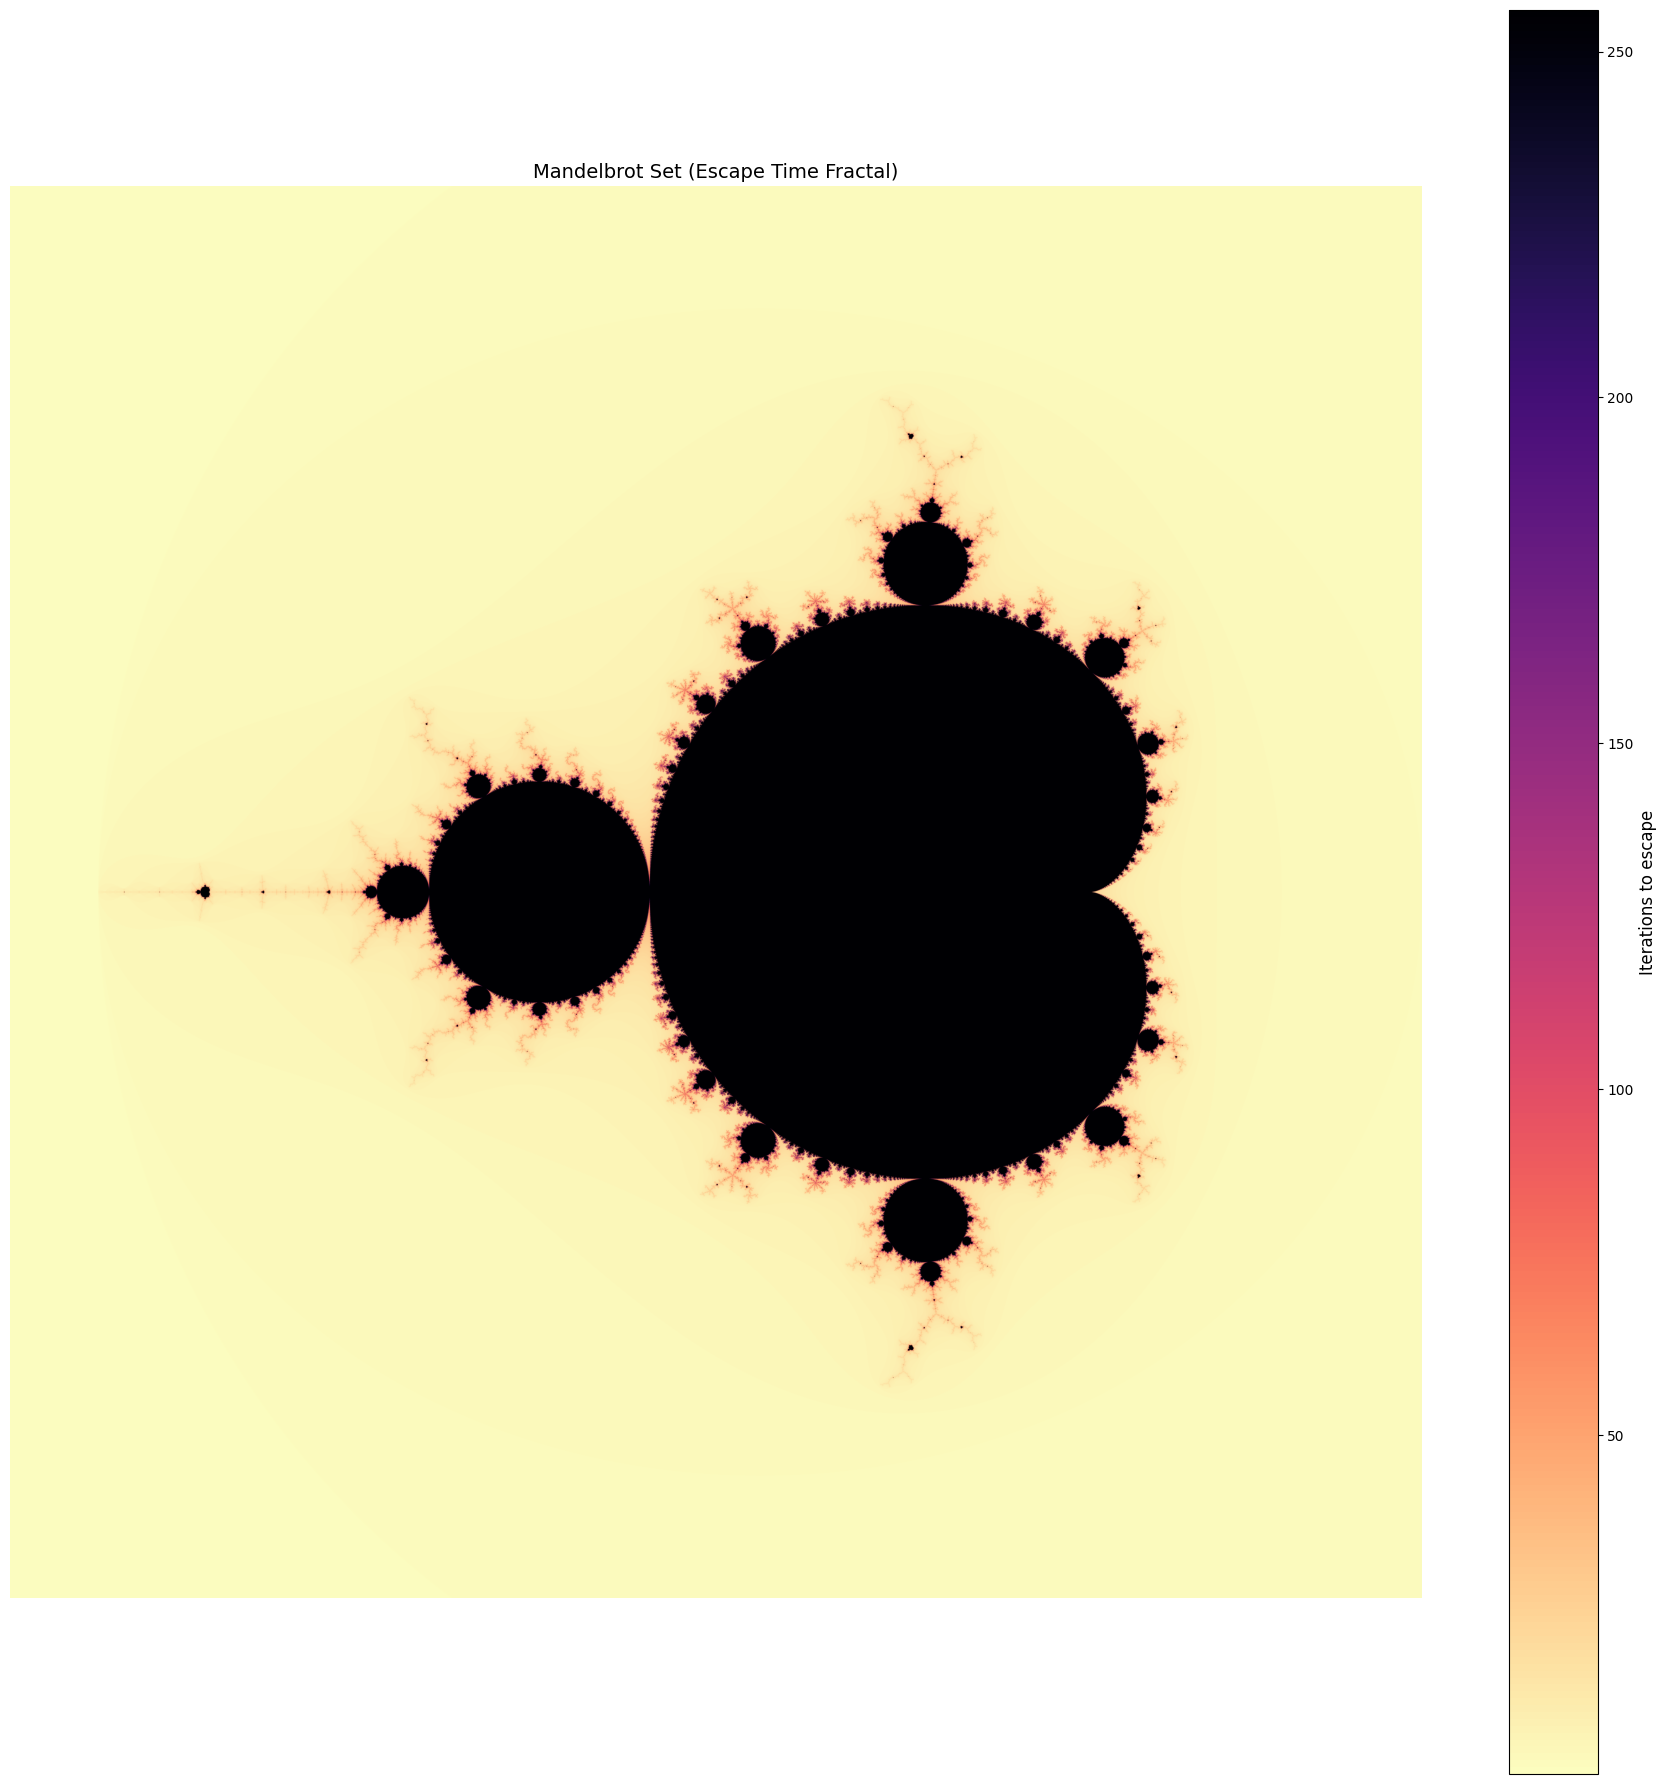

In [28]:
plotter_big = DynamicsPlotter(xmin, xmax, ymin, ymax, figsize=(18,18))

plotter_big.plot_escape_time_fractal(escape_times_mandelbrot, cmap='magma_r', title="Mandelbrot Set (Escape Time Fractal)", show_axis=False, show_axis_labels=False, show_colorbar=True, colorbar_label="Iterations to escape")

# Pruebo algunos parámetros $c$ y visualizo los tiempos de escape

### C's que me han gustado

**c = (0.2712619460530242+0.01650301990105929j)**

**c = (0.3823085582583369-0.4471788293483884j)**

**c = (0.49260297357728833-0.23362529372880392j)**

**c = (0.4613955974918197+0.7658647155670838j)**

**c = (0.41781625322728955-0.3661714534103587j)**

**c = (-1.3479999999999999+0j)**

**c = -0.33399999999999963-0.624j**

**c = (0.3160000000000003+0.5979999999999999j)**

**c = (-0.09999999999999964-1.014j)**

**c = (-0.7239999999999998+0j)**

**c = (-0.932) + (0.0)j**

**c = (-1.166+0.182j)**

**c = (0.29+0.52j)**

**c = (-1.79+0j)**


c = (-1.927393303914323-0.04073354858230882j)


c = (-0.40360361039769166+0.4771584356736751j)

In [ ]:
nice_c_parameters = [
    -0.70176 - 0.3842j,  # Intricate, connected spirals
    -0.8     + 0.156j,   # Sweeping, tree-like spirals
     0.285   + 0.01j,    # Douady Rabbit style
     0.29    + 0.52j,
    -0.4     + 0.6j,     # Thick swirls
    -0.334   - 0.624j,
    -0.835   - 0.2321j,  # Dense galaxy spirals
    -0.7269  + 0.1889j,  # Floating swirl islands
     0.355   + 0.355j,   # Sparse, starry dust
    -0.54    + 0.54j,    # Snowflake-like structure
    -0.08    + 0.836j,   # Jagged, lightning dendrites
    -0.123   + 0.745j,   # Stretched rabbit variant
     0.271   + 0.0165j,
     0.418   - 0.367j,
     0.382   - 0.447j,
     0.493   - 0.234j,
    -1.348   + 0j,
    -1.166   + 0.182j,
    -1.79    + 0j
]

In [286]:
for c in nice_c_parameters:
    z = 0
    iters = 0
    while abs(z) <= 2.0 and iters < max_iter:
        z = z*z + c
        iters += 1
    print(f"z0=0 evaluado en z^2 + {c}      \t se ha salido en {iters}\titeraciones")

z0=0 evaluado en z^2 + (-0.70176-0.3842j)      	 se ha salido en 16	iteraciones
z0=0 evaluado en z^2 + (-0.8+0.156j)      	 se ha salido en 252	iteraciones
z0=0 evaluado en z^2 + (0.285+0.01j)      	 se ha salido en 19	iteraciones
z0=0 evaluado en z^2 + (0.29+0.52j)      	 se ha salido en 256	iteraciones
z0=0 evaluado en z^2 + (-0.4+0.6j)      	 se ha salido en 26	iteraciones
z0=0 evaluado en z^2 + (-0.334-0.624j)      	 se ha salido en 26	iteraciones
z0=0 evaluado en z^2 + (-0.835-0.2321j)      	 se ha salido en 39	iteraciones
z0=0 evaluado en z^2 + (-0.7269+0.1889j)      	 se ha salido en 256	iteraciones
z0=0 evaluado en z^2 + (0.355+0.355j)      	 se ha salido en 28	iteraciones
z0=0 evaluado en z^2 + (-0.54+0.54j)      	 se ha salido en 132	iteraciones
z0=0 evaluado en z^2 + (-0.08+0.836j)      	 se ha salido en 30	iteraciones
z0=0 evaluado en z^2 + (-0.123+0.745j)      	 se ha salido en 256	iteraciones
z0=0 evaluado en z^2 + (0.271+0.0165j)      	 se ha salido en 256	iteraciones
z0

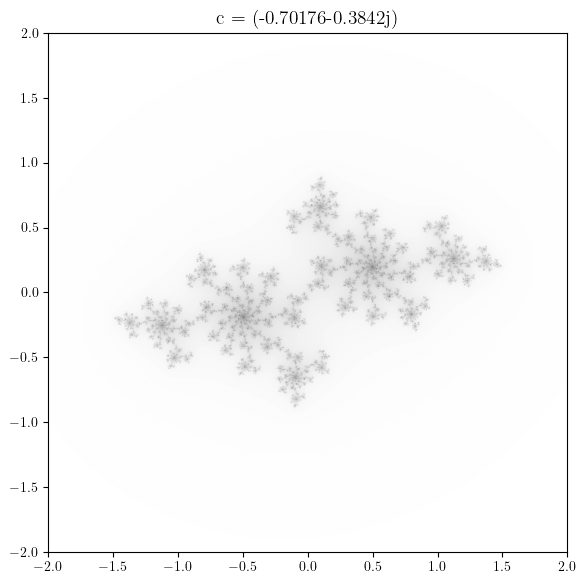

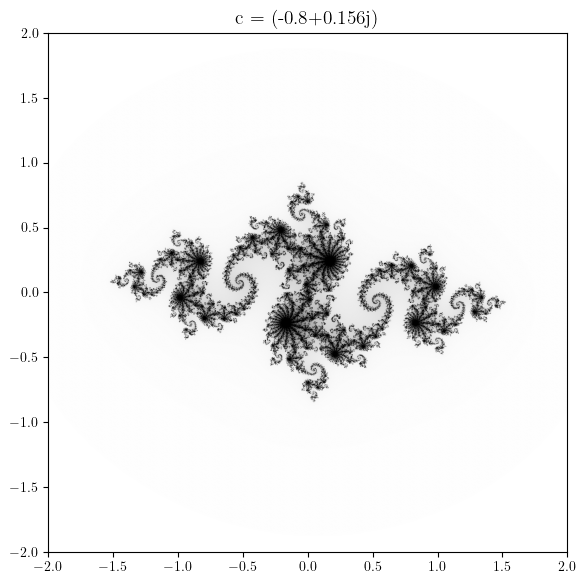

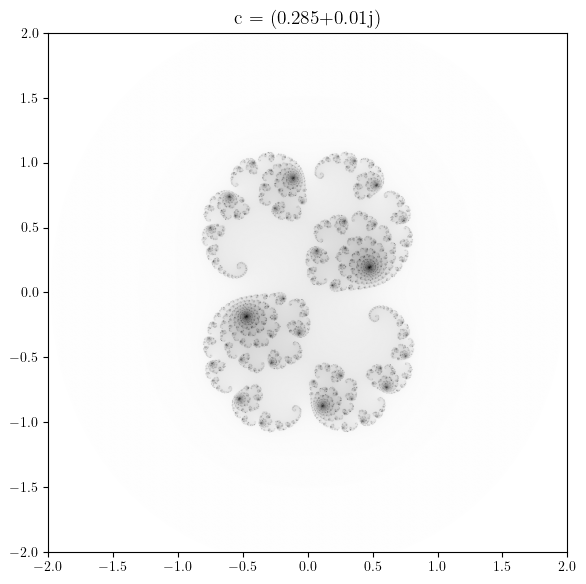

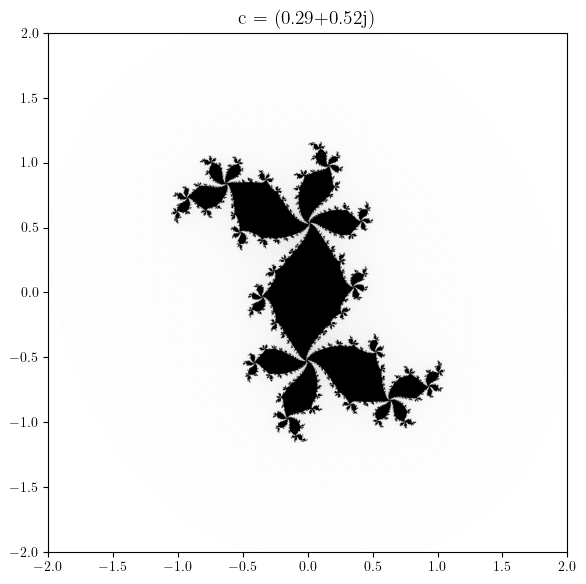

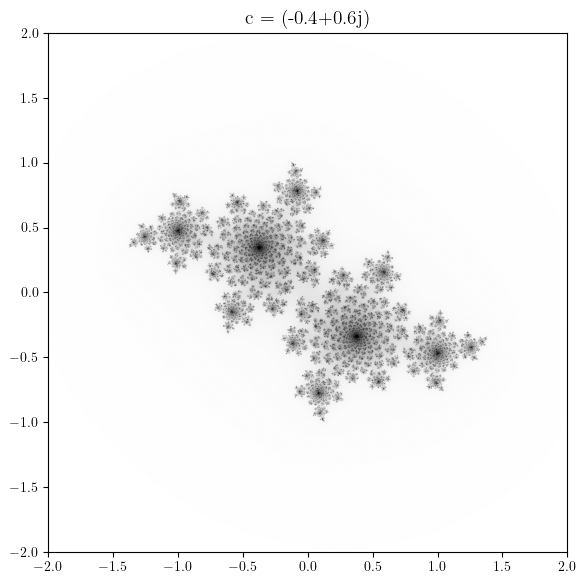

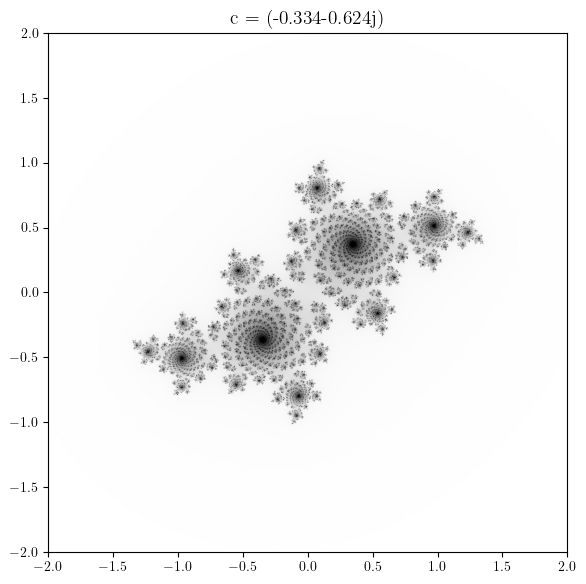

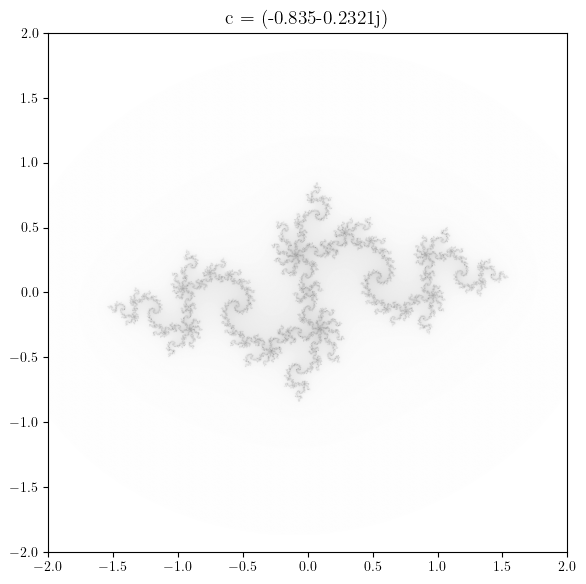

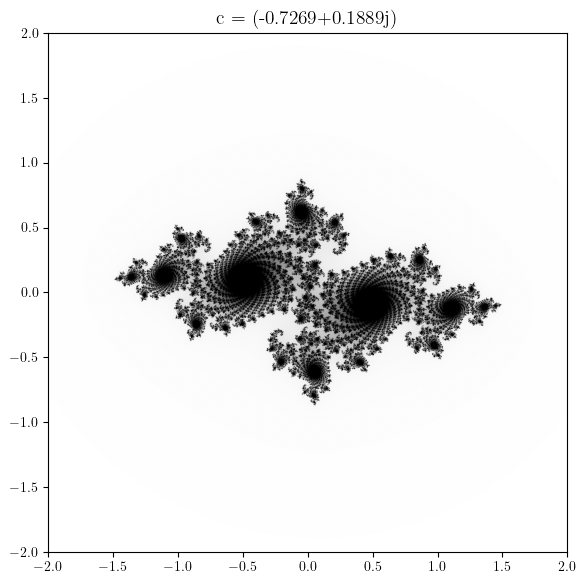

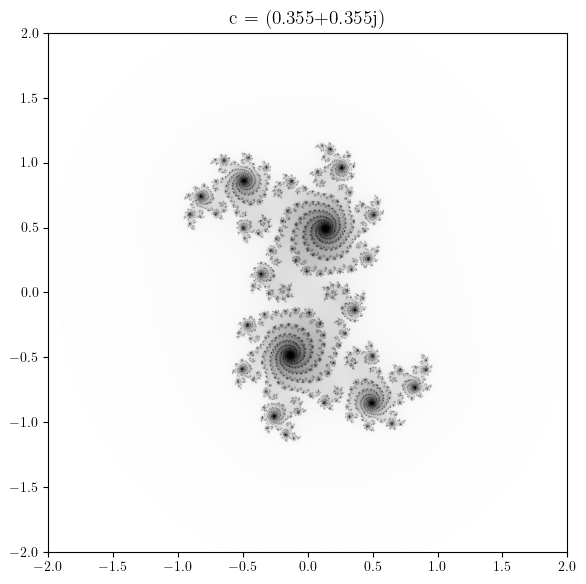

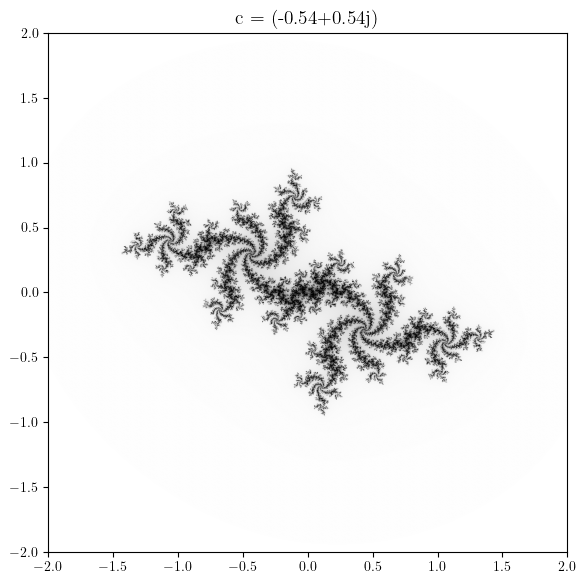

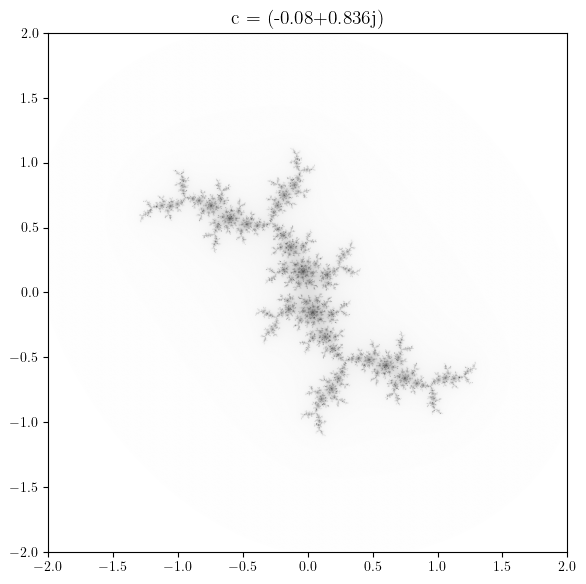

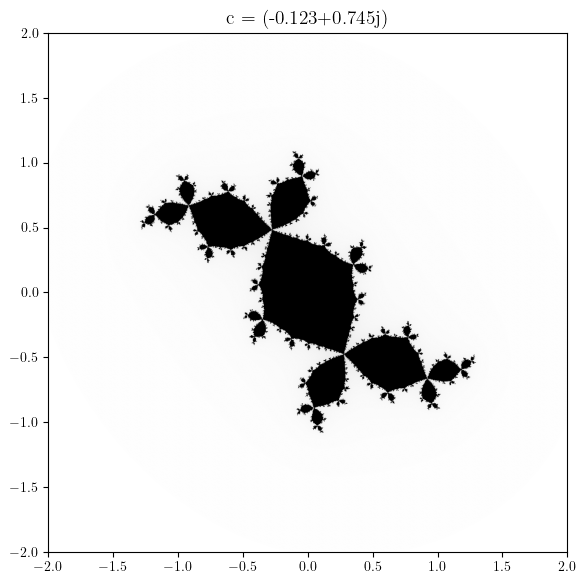

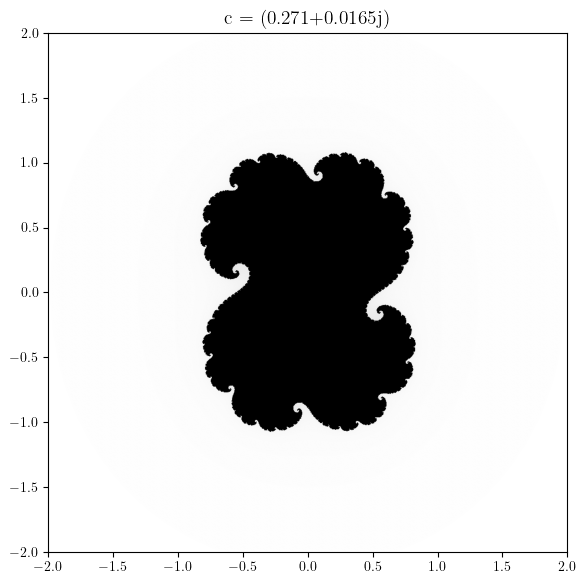

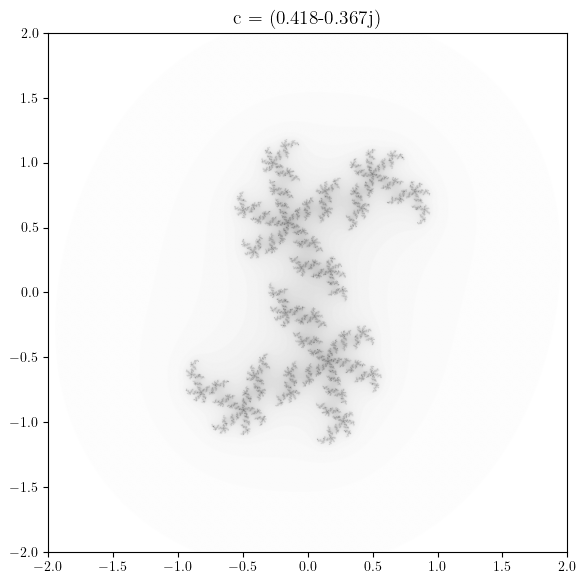

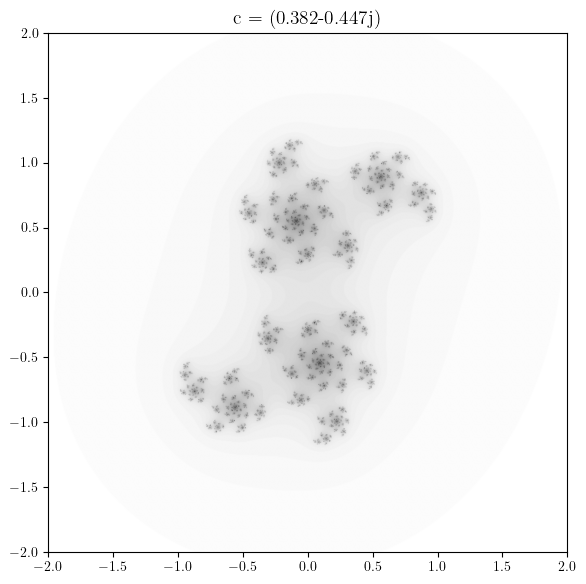

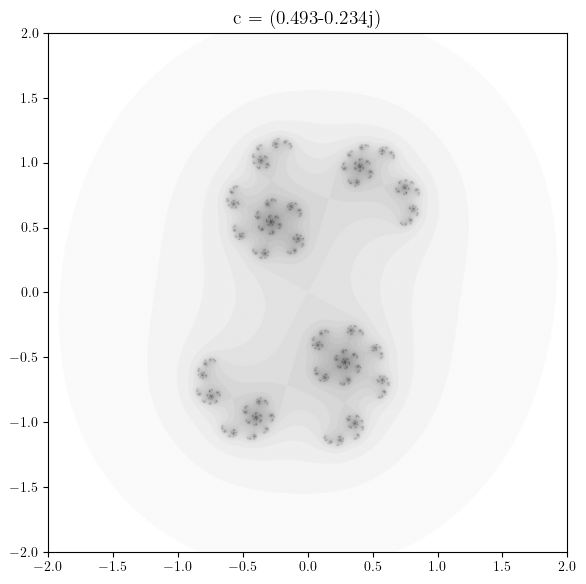

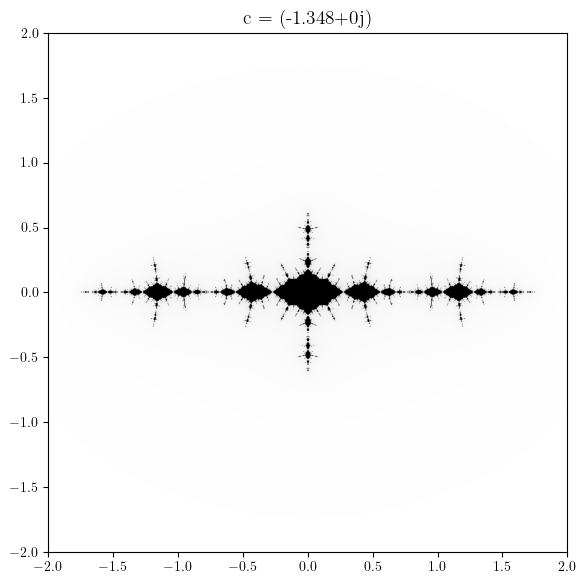

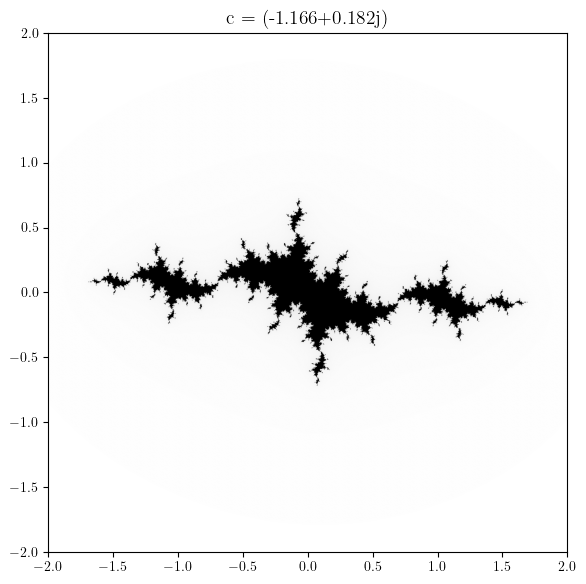

In [273]:
for c in nice_c_parameters:
    @njit
    def R2c_nice(z):
        return z**2 + c

    generate_escape_time_fractal_for_R2c_nice = make_generate_escape_time_fractal_jitted(R2c_nice)

    center = 0.0
    max_distance_to_center = 2.0

    xmin = center.real-max_distance_to_center
    xmax = center.real+max_distance_to_center
    ymin = center.imag-max_distance_to_center
    ymax = center.imag+max_distance_to_center

    horizontal_pixels = 1000
    vertical_pixels = 1000

    max_iter = 256

    escape_times = generate_escape_time_fractal_for_R2c_nice(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=1e10)

    plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

    # Plot 1: The escape time fractal
    plotter.plot_escape_time_fractal(escape_times, title=rf"c = {c}")

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'c = (-0.334-0.624j)'}>)

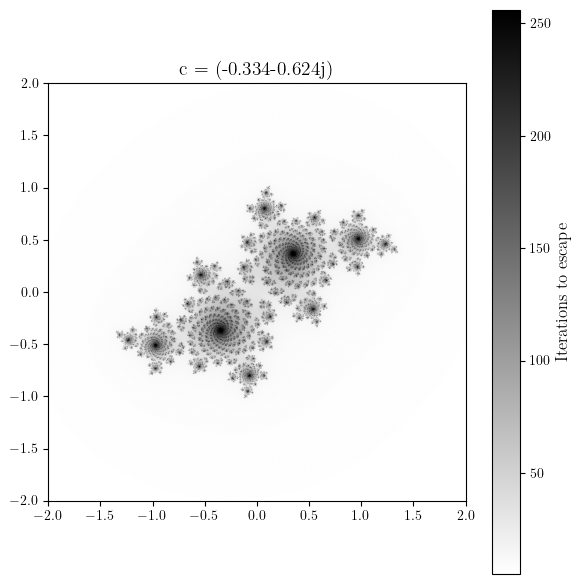

In [ ]:
index = 5
c = nice_c_parameters[index]

@njit
def R2c_nice(z):
    return z**2 + c

generate_escape_time_fractal_for_R2c_nice = make_generate_escape_time_fractal_jitted(R2c_nice)

center = 0.0
max_distance_to_center = 2.0

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 256

escape_times = generate_escape_time_fractal_for_R2c_nice(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=1e10)

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

# Plot 1: The escape time fractal
plotter.plot_escape_time_fractal(escape_times, title=rf"c = {c}", show_colorbar=True)

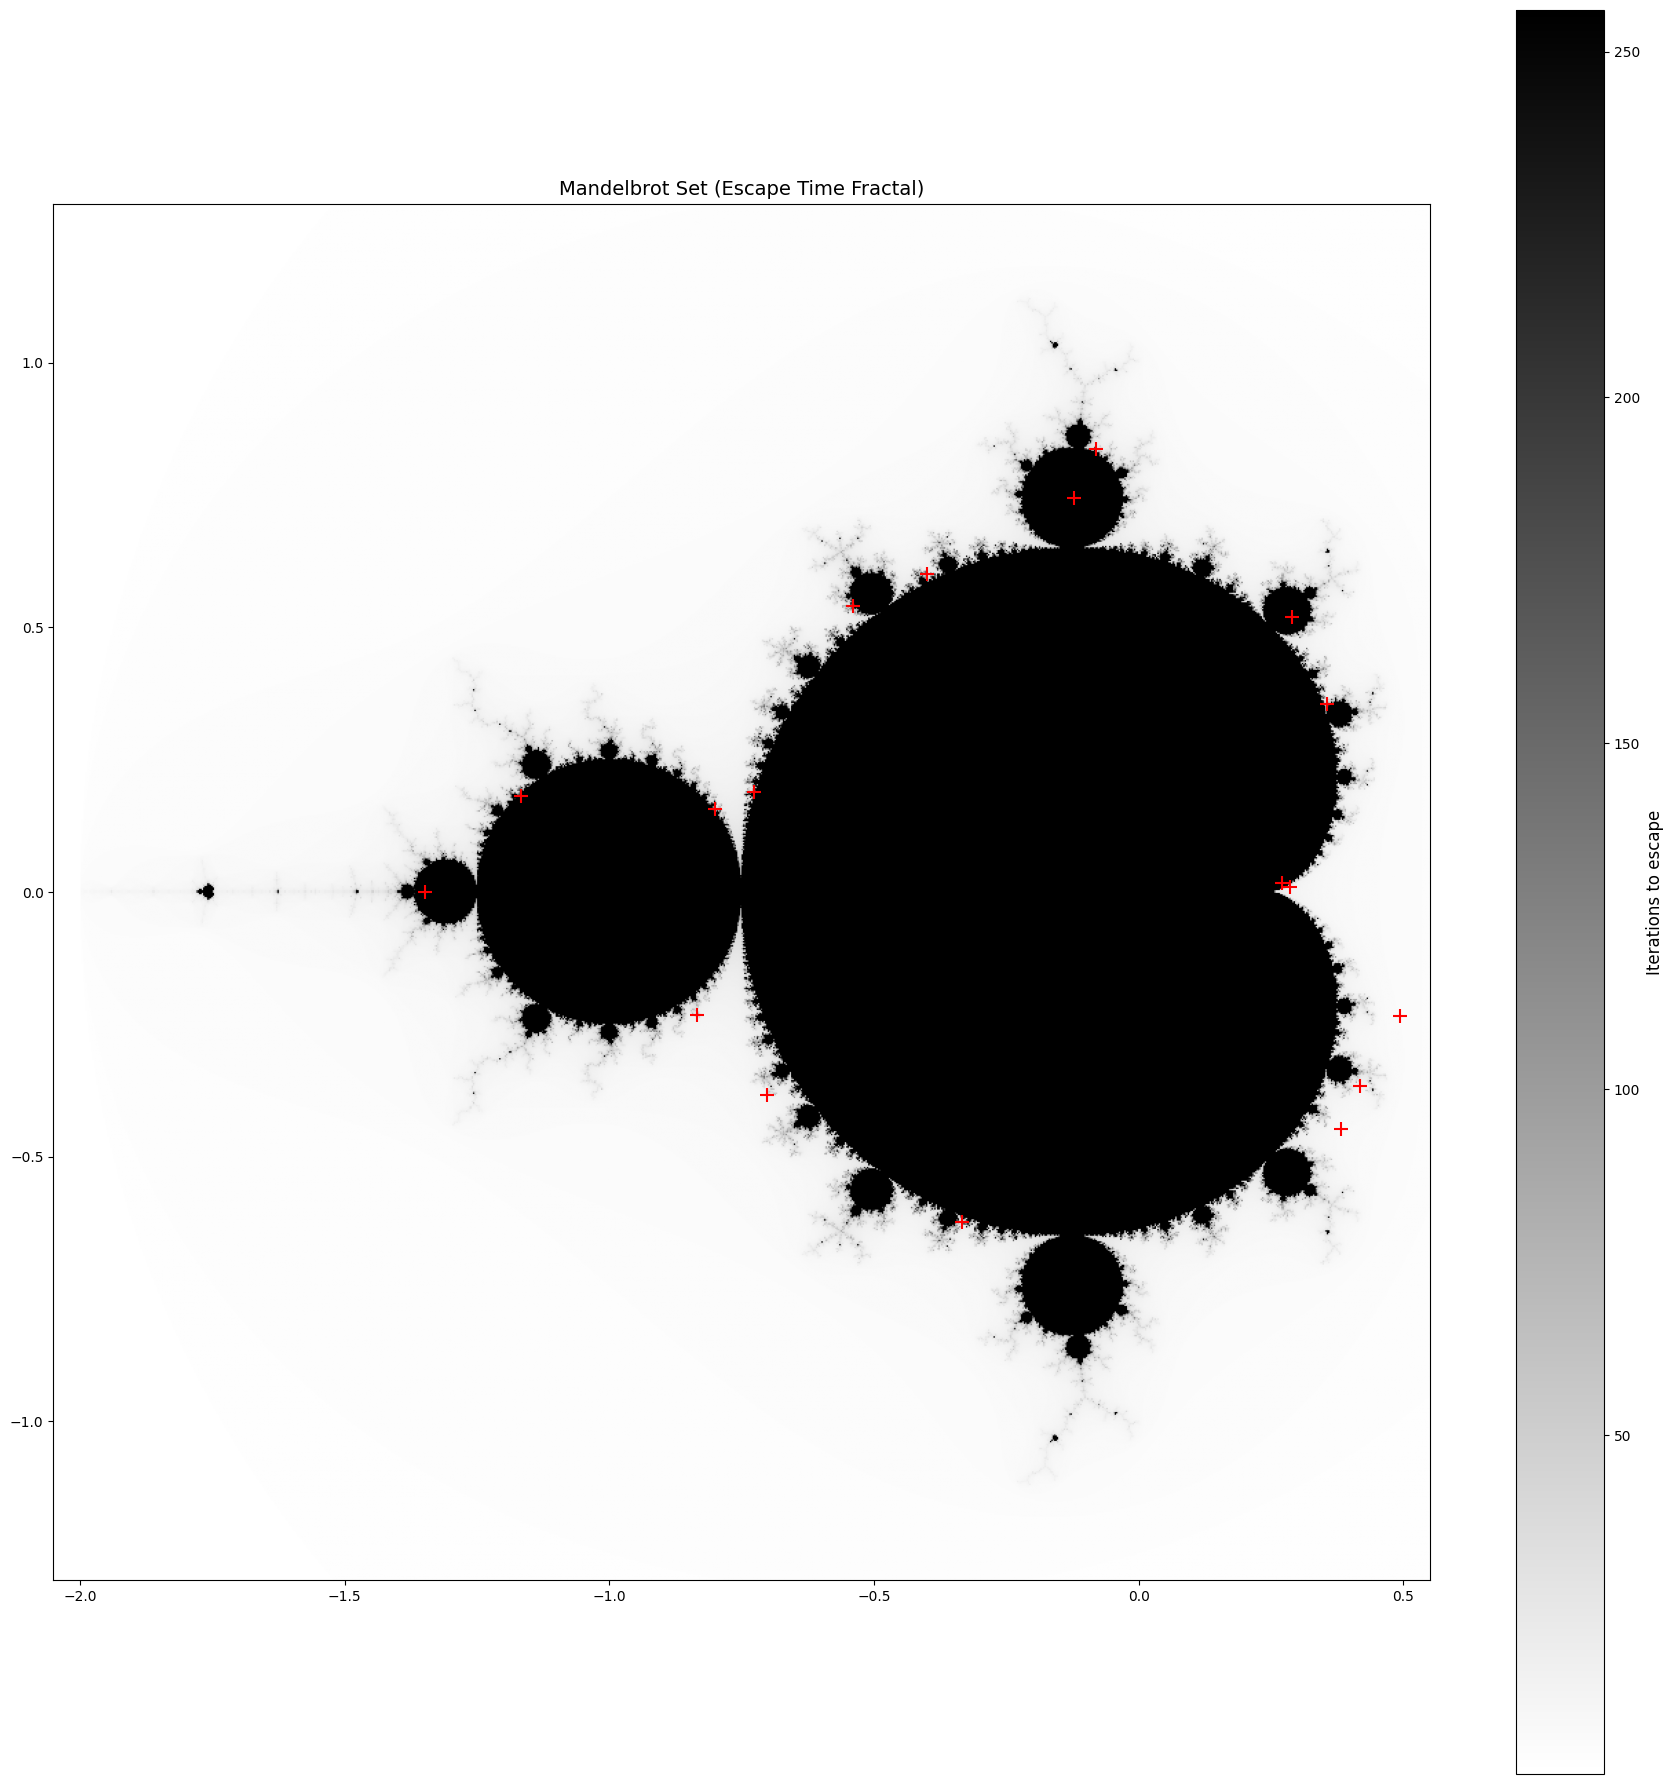

In [288]:
center = -0.75
max_distance_to_center = 1.3

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

size_in_pixels = 1000

max_iter = 256

escape_times_mandelbrot_for_choosing_c = generate_escape_times_for_mandelbrot_set(xmin, xmax, ymin, ymax, size_in_pixels, size_in_pixels, max_iter=max_iter, escape_radius=2.0)

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, figsize = (18, 18))

fig, ax = plotter.plot_escape_time_fractal(escape_times_mandelbrot_for_choosing_c, title="Mandelbrot Set (Escape Time Fractal)", show_colorbar=True)

for c in nice_c_parameters:
    plotter.add_points(ax, [c], marker="+", color='red', s=100)

## Random parameter

In [289]:
import math

center = -0.75
max_distance_to_center = 1.3

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

size_in_pixels = 100

max_iter = 256
decimal_precission = math.ceil(np.log10(max_iter))

escape_times_mandelbrot_for_choosing_c = generate_escape_times_for_mandelbrot_set(xmin, xmax, ymin, ymax, size_in_pixels, size_in_pixels, max_iter=max_iter, escape_radius=2.0)

possible_c = []

y = 0
for row in escape_times_mandelbrot_for_choosing_c:
    x = 0
    for escape_time in row:
        if escape_time >= 3:
            c_real = xmin + x/size_in_pixels*2*max_distance_to_center
            c_imag = ymin + y/size_in_pixels*2*max_distance_to_center
            
            c_real = np.round(c_real, decimal_precission)
            c_imag = np.round(c_imag, decimal_precission)

            c = complex(c_real, c_imag)
            possible_c.append(c)
        x += 1
    y += 1

c = (-1.79+0j)


(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': '$c = (-1.79+0j)$'}>)

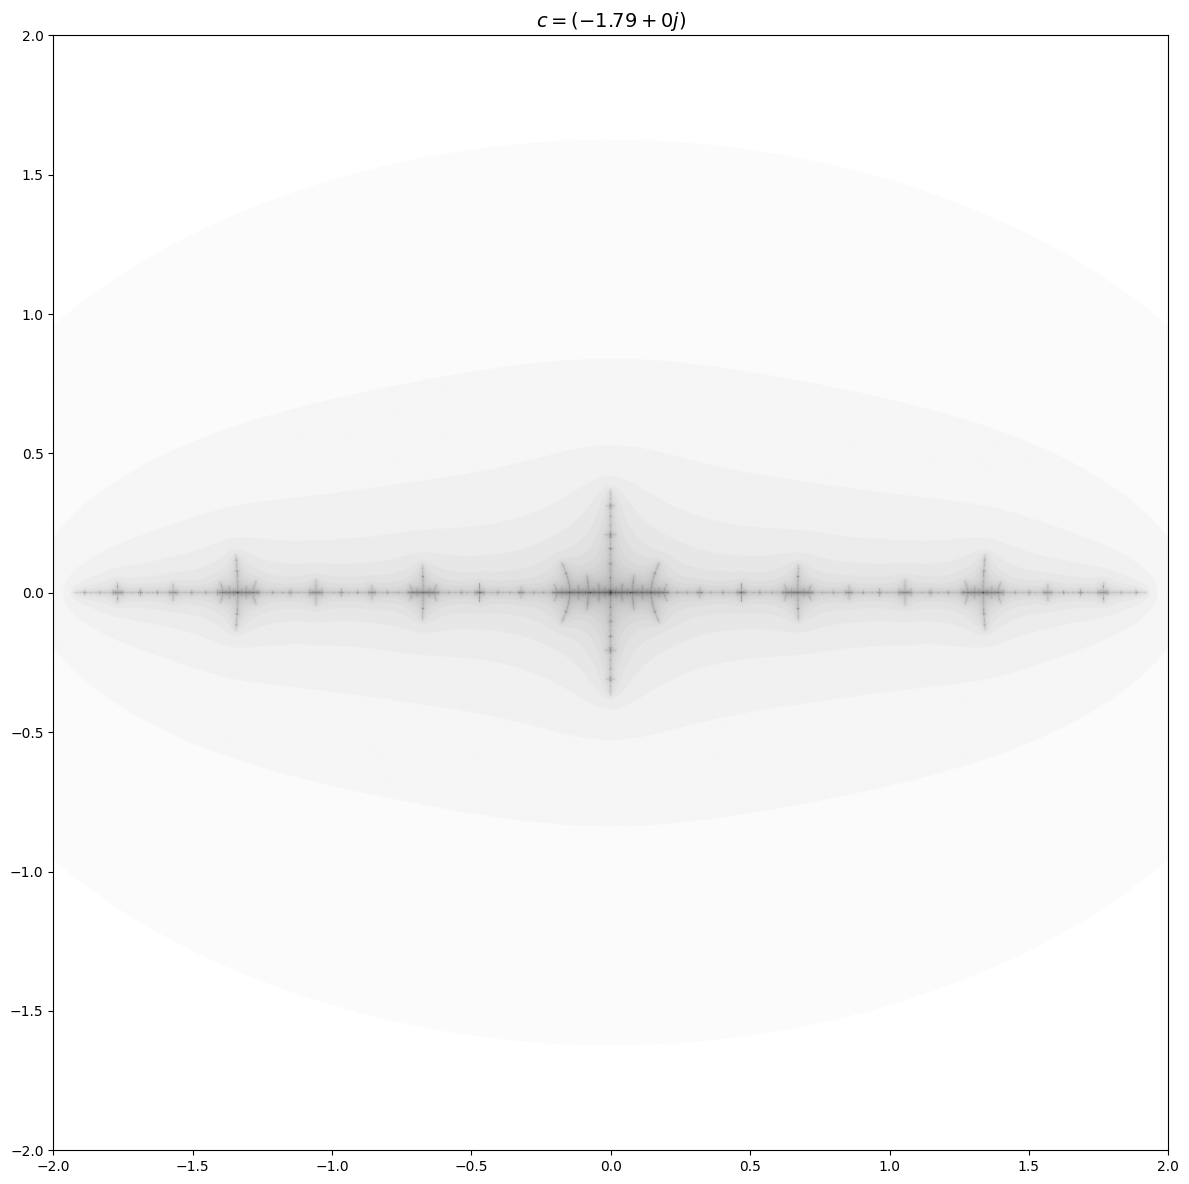

In [291]:
c = possible_c[np.random.randint(0, len(possible_c))]

print(rf"c = {c}")

@njit
def R2c_random(z):
    return z**2 + c

generate_escape_time_fractal_for_R2c_random = make_generate_escape_time_fractal_jitted(R2c_random)

center = 0.0
max_distance_to_center = 2.0

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 2048
vertical_pixels = 2048

max_iter = 2048

escape_times = generate_escape_time_fractal_for_R2c_random(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=1e10)

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, figsize=(12,12))

# Plot 1: The escape time fractal
plotter.plot_escape_time_fractal(escape_times, title=rf"$c = {c}$")

# Plot 2: Just the Julia set (the delicate boundary curve)
# plotter.plot_julia_set_from_escape_times(escape_times, max_iter=max_iter)

iteration 0:    c = (0.082-0.208j)
iteration 1:    c = (0.03+0.546j)
iteration 2:    c = (-1.14-0.442j)
iteration 3:    c = (-1.764-0.104j)
iteration 4:    c = (-0.542+0.26j)
iteration 5:    c = (0.186+0.806j)
iteration 6:    c = (0.29+0.52j)
iteration 7:    c = (-1.452-0.208j)
iteration 8:    c = (-0.49-0.676j)
iteration 9:    c = (-0.1-0.416j)


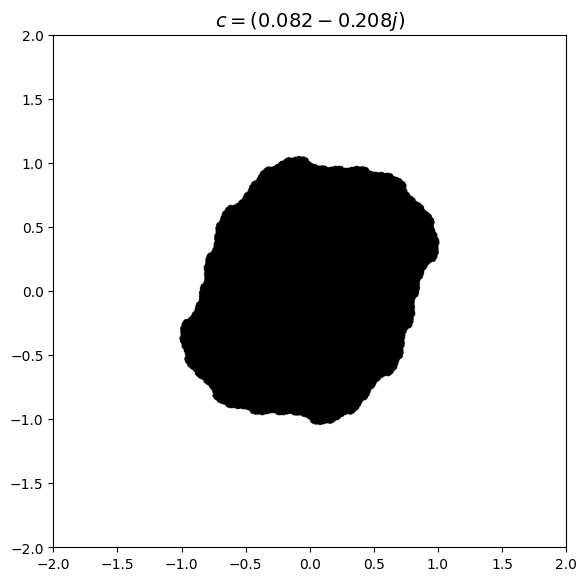

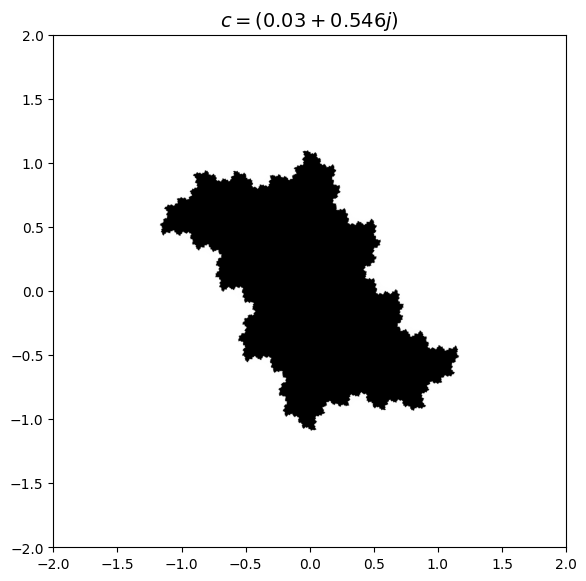

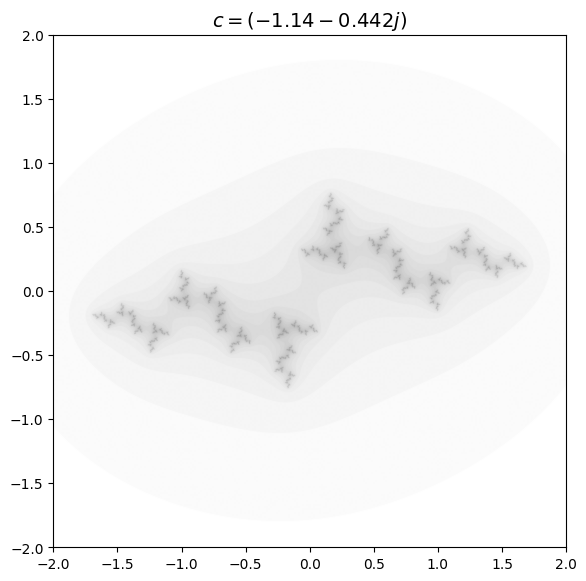

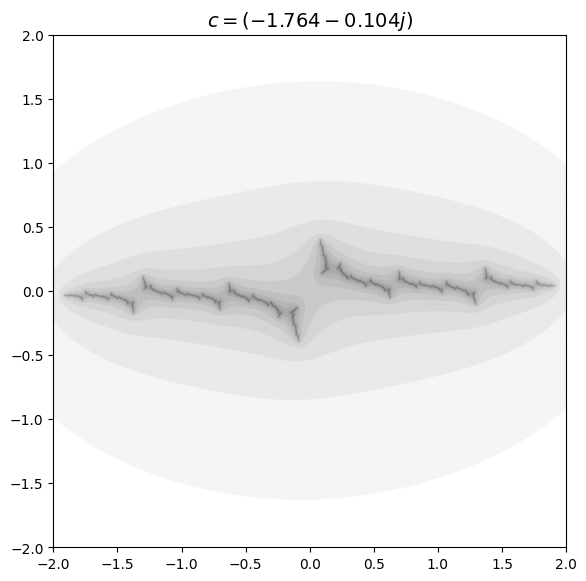

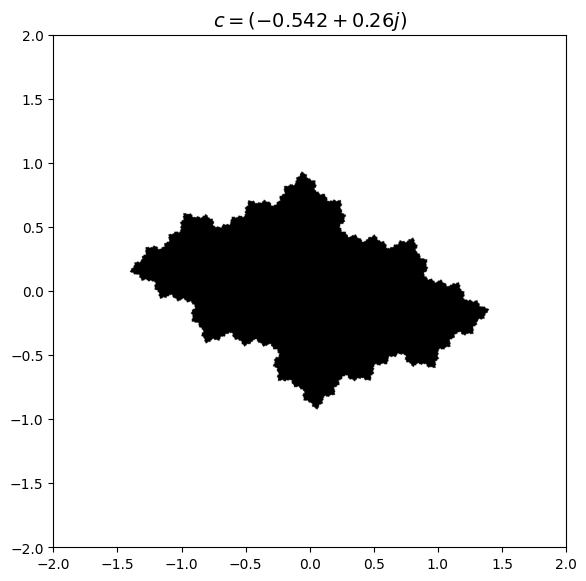

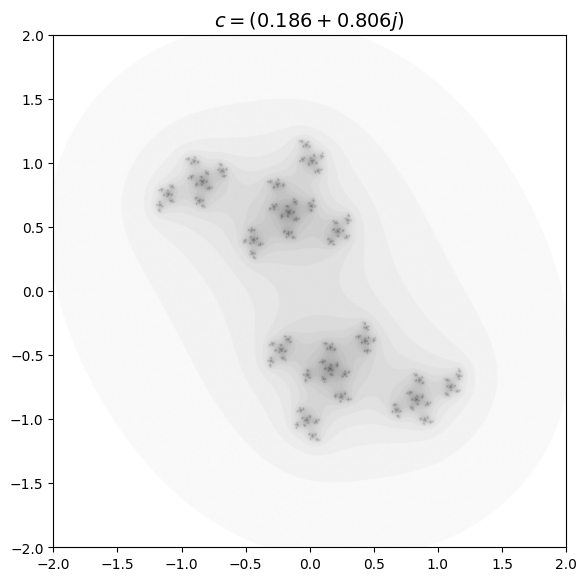

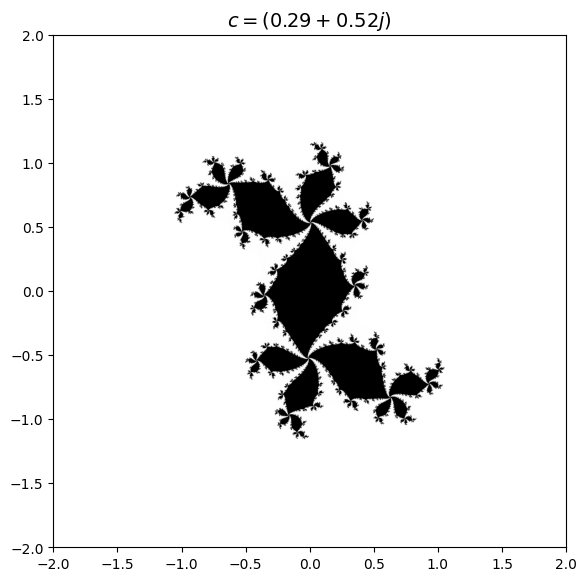

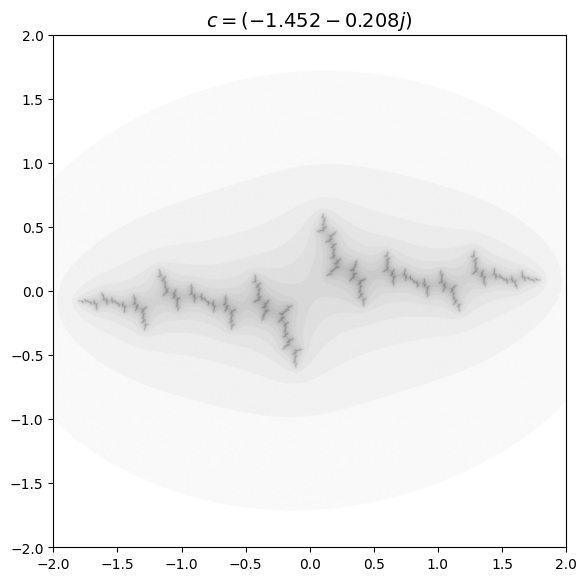

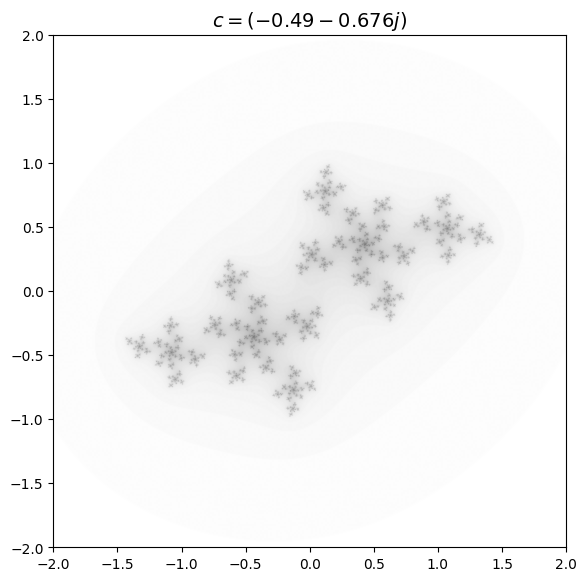

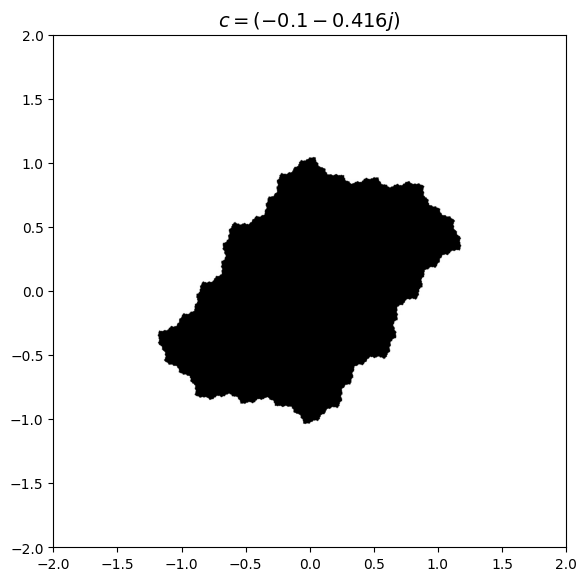

In [259]:
for i in range(10):
    c = possible_c[np.random.randint(0, len(possible_c))]

    print(rf"iteration {i}:    c = {c}")

    @njit
    def R2c_random(z):
        return z**2 + c

    generate_escape_time_fractal_for_R2c_random = make_generate_escape_time_fractal_jitted(R2c_random)

    center = 0.0
    max_distance_to_center = 2.0

    xmin = center.real-max_distance_to_center
    xmax = center.real+max_distance_to_center
    ymin = center.imag-max_distance_to_center
    ymax = center.imag+max_distance_to_center

    horizontal_pixels = 2048
    vertical_pixels = 2048

    max_iter = 2048

    escape_times = generate_escape_time_fractal_for_R2c_random(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=1e10)

    plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

    # Plot 1: The escape time fractal
    plotter.plot_escape_time_fractal(escape_times, title=rf"$c = {c}$")

    # Plot 2: Just the Julia set (the delicate boundary curve)
    # plotter.plot_julia_set_from_escape_times(escape_times, max_iter=max_iter)